In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"E:\2_projects\7_2B_Project\Data\Supply_Chain_dataset.csv")

df['shipping_date_(DateOrders)'] = pd.to_datetime(df['shipping_date_(DateOrders)'])
df = df.drop(columns="Order_Zipcode")
df = df.drop(columns="Product_Description")
df = df.dropna()

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 180508 entries, 0 to 180518
Data columns (total 51 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   Type                           180508 non-null  object        
 1   Days_for_shipping_(real)       180508 non-null  int64         
 2   Days_for_shipment_(scheduled)  180508 non-null  int64         
 3   Benefit_per_order              180508 non-null  float64       
 4   Sales_per_customer             180508 non-null  float64       
 5   Delivery_Status                180508 non-null  object        
 6   Late_delivery_risk             180508 non-null  int64         
 7   Category_Id                    180508 non-null  int64         
 8   Category_Name                  180508 non-null  object        
 9   Customer_City                  180508 non-null  object        
 10  Customer_Country               180508 non-null  object        
 11  Custo

In [20]:
df.head()

,Type,Days_for_shipping_(real),Days_for_shipment_(scheduled),Benefit_per_order,Sales_per_customer,Delivery_Status,Late_delivery_risk,Category_Id,Category_Name,Customer_City,...,Order_State,Order_Status,Product_Card_Id,Product_Category_Id,Product_Image,Product_Name,Product_Price,Product_Status,shipping_date_(DateOrders),Shipping_Mode
0,DEBIT,3,4,91.25000,314.64001,Advance shipping,0,73,Sporting Goods,Caguas,...,Java Occidental,COMPLETE,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2018-02-03,Standard Class
1,TRANSFER,5,4,-249.09000,311.35999,Late delivery,1,73,Sporting Goods,Caguas,...,Rajastan,PENDING,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2018-01-18,Standard Class
2,CASH,4,4,-247.78000,309.72000,Shipping on time,0,73,Sporting Goods,San Jose,...,Rajastan,CLOSED,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2018-01-17,Standard Class
3,DEBIT,3,4,22.86000,304.81000,Advance shipping,0,73,Sporting Goods,Los Angeles,...,Queensland,COMPLETE,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2018-01-16,Standard Class
4,PAYMENT,2,4,134.21001,298.25000,Advance shipping,0,73,Sporting Goods,Caguas,...,Queensland,PENDING_PAYMENT,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2018-01-15,Standard Class


### EDA_Function : 
Calculates and displays the main descriptive statistics of a numerical variable for exploratory data analysis (EDA).

In [21]:
def EDA (x):
    min_value = x.min()
    max_value = x.max()

    mode_value = x.mode()[0]
    mean_value = x.mean()

    first_quartile = x.quantile(0.25)
    median_value = x.median()
    third_quartile = x.quantile(0.75)

    var = x.var()
    std = x.std()

    skewness = x.skew()
    kurtosis = x.kurtosis()


    print("Minimum: ", min_value)
    print("Maximum: ", max_value)
    print("Mean: ", mean_value)
    print("Mode: ", mode_value)
    print("First Quartile: ", first_quartile)
    print("Median: ", median_value)
    print("Third Quartile: ", third_quartile)
    print("Variance: ", var)
    print("Standard Deviation: ", std)
    print("Skewness: ", skewness)
    print("Kurtosis: ", kurtosis)

In [22]:
EDA(df['Sales_per_customer'])

Minimum:  7.49
Maximum:  1939.98999
Mean:  183.10175147721986
Mode:  122.84
First Quartile:  104.38
Median:  163.99001
Third Quartile:  247.39999
Variance:  14409.980462803878
Standard Deviation:  120.0415780586205
Skewness:  2.888772298704486
Kurtosis:  23.924135364639522


In [23]:
EDA(df['Benefit_per_order'])

Minimum:  -4274.97998
Maximum:  911.79999
Mean:  21.97156322079908
Mode:  0.0
First Quartile:  7.0
Median:  31.52
Third Quartile:  64.8
Variance:  10906.431105151245
Standard Deviation:  104.4338599552427
Skewness:  -4.742049775421545
Kurtosis:  71.3801020540034


In [24]:
EDA(df['Order_Profit_Per_Order']) #‼️‼️ we should delete this column because it is the same as Benefit_per_order

Minimum:  -4274.98
Maximum:  911.8
Mean:  21.97156314401578
Mode:  0.0
First Quartile:  7.0
Median:  31.52
Third Quartile:  64.8
Variance:  10906.431125787482
Standard Deviation:  104.43386005404321
Skewness:  -4.742049803514203
Kurtosis:  71.38010239843567


In [25]:
df.drop('Order_Profit_Per_Order', axis=1, inplace=True)

In [26]:
EDA(df['Order_Item_Discount'])

Minimum:  0.0
Maximum:  500.0
Mean:  20.663998380902783
Mode:  0.0
First Quartile:  5.4
Median:  14.0
Third Quartile:  29.99
Variance:  475.2728414350553
Standard Deviation:  21.800753230910516
Skewness:  3.040034438011397
Kurtosis:  25.233961186727715


In [27]:
EDA(df['Order_Item_Profit_Ratio'])

Minimum:  -2.75
Maximum:  0.5
Mean:  0.12063880825226583
Mode:  0.48
First Quartile:  0.08
Median:  0.27
Third Quartile:  0.36
Variance:  0.21790777553793741
Standard Deviation:  0.4668059292017802
Skewness:  -2.8934720553984237
Kurtosis:  10.156661051596174


In [28]:
EDA(df['Sales'])

Minimum:  9.99
Maximum:  1999.98999
Mean:  203.7654964663616
Mode:  129.99001
First Quartile:  119.98
Median:  199.92
Third Quartile:  299.95001
Variance:  17495.561186226398
Standard Deviation:  132.27078735014166
Skewness:  2.884585498745443
Kurtosis:  23.940361379786516


In [29]:
# as we noticed, there are may some columns with same values, regarding they have diff columns names.
# so used my ai assistant to check every column 
# then delete it

duplicate_cols = []

for i in range(len(df.columns)):
    for j in range(i + 1, len(df.columns)):
        if df.iloc[:, i].equals(df.iloc[:, j]):
            print(f"{df.columns[i]}  <-->  {df.columns[j]}")
            duplicate_cols.append(df.columns[j])  # Keep the first, mark the second

df = df.drop(columns=duplicate_cols)

print("Dropped columns:", duplicate_cols)

Sales_per_customer  <-->  Order_Item_Total
Category_Id  <-->  Product_Category_Id
Customer_Email  <-->  Customer_Password
Customer_Id  <-->  Order_Customer_Id
Order_Item_Cardprod_Id  <-->  Product_Card_Id
Dropped columns: ['Order_Item_Total', 'Product_Category_Id', 'Customer_Password', 'Order_Customer_Id', 'Product_Card_Id']


### EDA_Plots(descriptive 0nly):
Here, we will answer some basic business questions.

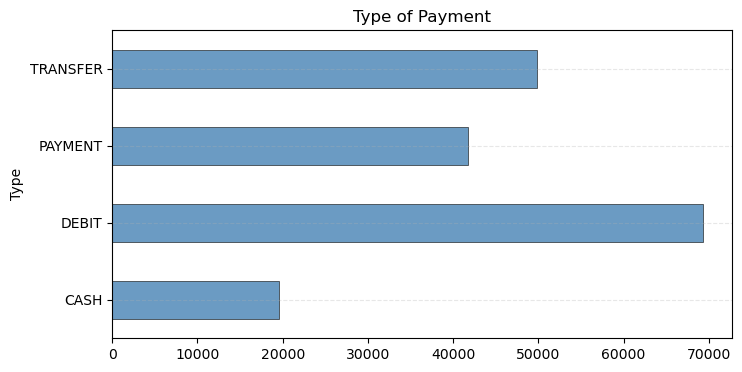

In [30]:
ax= df.groupby(['Type'])['Type'].count().plot(kind='barh', title='Type of Payment', figsize=(8, 4), alpha=0.8, color='steelblue', edgecolor='black', linewidth=0.5)
ax.grid(axis='y', linestyle='--', alpha=0.3)

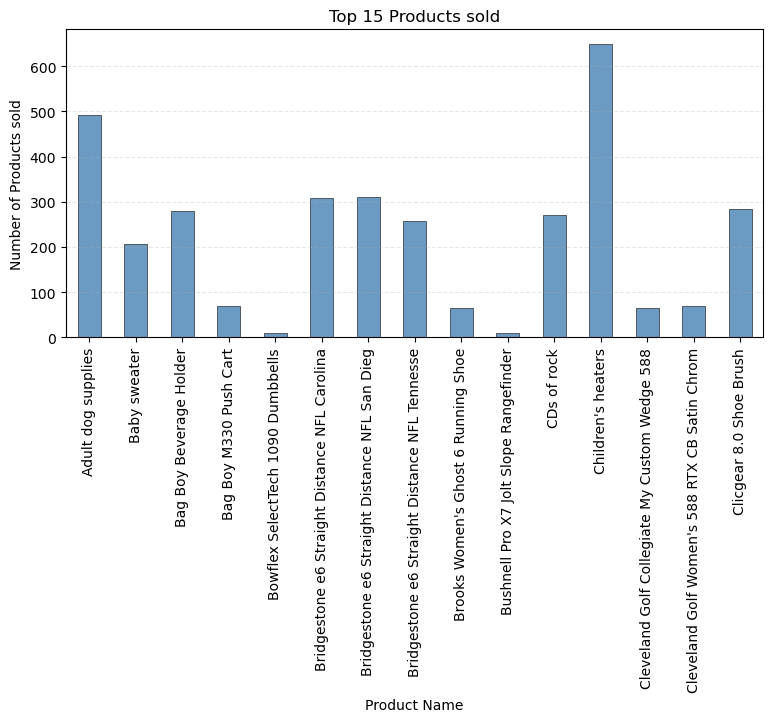

In [31]:
ax= df.groupby(['Product_Name'])['Product_Name'].count().head(15).plot(kind='bar', title='Top 15 Products sold', figsize=(9, 4), xlabel='Product Name', ylabel='Number of Products sold' , alpha=0.8, color='steelblue', edgecolor='black', linewidth=0.5) 
ax.grid(axis='y', linestyle='--', alpha=0.3)

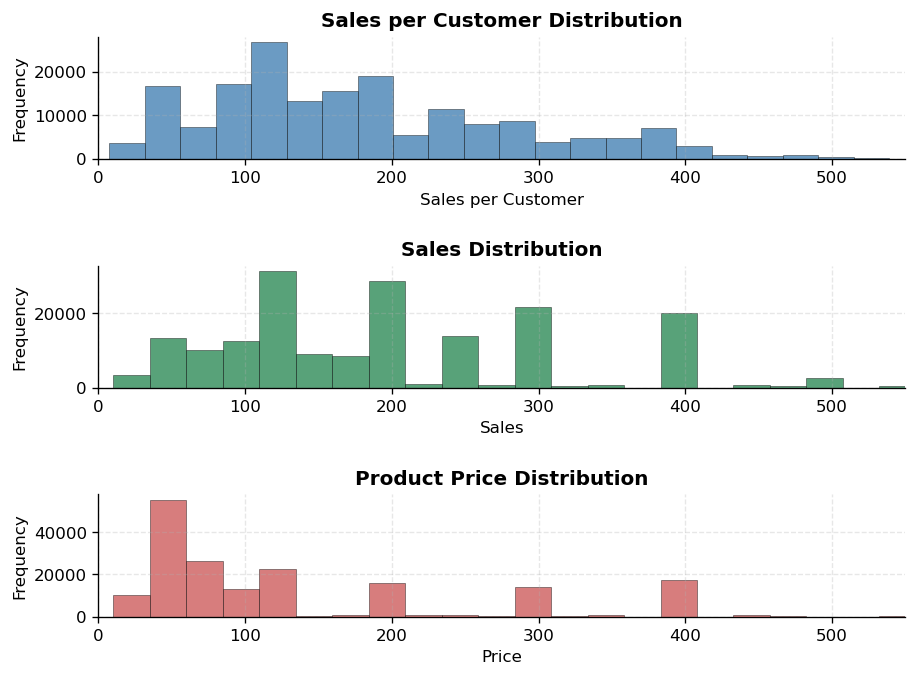

In [32]:
fig, ax = plt.subplots(3, 1, figsize=(8, 6), dpi=120)

ax[0].hist(df['Sales_per_customer'], bins=80, alpha=0.8,
           color='steelblue', edgecolor='black', linewidth=0.3)
ax[0].set_title('Sales per Customer Distribution', fontsize=12, fontweight='bold')
ax[0].set_xlabel('Sales per Customer')
ax[0].set_ylabel('Frequency')
ax[0].set_xlim(0, 550)
ax[0].grid(alpha=0.3, linestyle='--')
ax[0].spines['top'].set_visible(False)
ax[0].spines['right'].set_visible(False)

ax[2].hist(df['Product_Price'], bins=80, alpha=0.8,
           color='indianred', edgecolor='black', linewidth=0.3)
ax[2].set_title('Product Price Distribution', fontsize=12, fontweight='bold')
ax[2].set_xlabel('Price')
ax[2].set_ylabel('Frequency')
ax[2].set_xlim(0, 550)
ax[2].grid(alpha=0.3, linestyle='--')
ax[2].spines['top'].set_visible(False)
ax[2].spines['right'].set_visible(False)

ax[1].hist(df['Sales'], bins=80, alpha=0.8,
           color='seagreen', edgecolor='black', linewidth=0.3)
ax[1].set_title('Sales Distribution', fontsize=12, fontweight='bold')
ax[1].set_xlabel('Sales')
ax[1].set_ylabel('Frequency')
ax[1].set_xlim(0, 550)
ax[1].grid(alpha=0.3, linestyle='--')
ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)

plt.tight_layout(pad=2)
plt.show()